In [116]:
import pandas as pd
import kagglehub
import os

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

# path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
# csv_path = os.path.join(path, "Reviews.csv")
# csv_path = os.path.join('Reviews.csv')

df = pd.read_csv('Reviews.csv', engine='python', on_bad_lines='skip')

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

### Basic visualization

In [117]:
display(df.head(10))

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [118]:
skip = [ 0, 2, 3, 7 ]
cols = [ i for i in range(len(df.columns)) if i not in skip ] # remove the columns that i'll not use

df = pd.read_csv('Reviews.csv', engine='python', on_bad_lines='skip', usecols=cols)

display(df.head(10))

,ProductId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text
0,B001E4KFG0,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,0,0,5,Great taffy,Great taffy at a great price. There was a wid...
5,B006K2ZZ7K,0,0,4,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,B006K2ZZ7K,0,0,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,B006K2ZZ7K,0,0,5,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,B000E7L2R4,1,1,5,Yay Barley,Right now I'm mostly just sprouting this so my...
9,B00171APVA,0,0,5,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [119]:
df.shape

(32068, 6)

### Check if we have any missing values

In [120]:
df.isna().sum()

,0
ProductId,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Summary,0
Text,0


Check total values of each column

In [125]:
print(df[['ProductId']].value_counts())
print('-' * 40)

print(df[['HelpfulnessNumerator']].value_counts())
print('-' * 40)

print(df[['HelpfulnessDenominator']].value_counts())
print('-' * 40)

print(df[['Score']].value_counts())
print('-' * 40)

# print(df[['Summary']].value_counts())
# print('-' * 40)

# print(df[['Text']].value_counts())
# print('-' * 40)


ProductId 
B002QWP89S    632
B007M83302    564
B0013NUGDE    564
B000KV61FC    556
B000PDY3P0    487
             ... 
B000084EKD      1
B000084EKC      1
B000084EKB      1
B000084EKA      1
B000084EK8      1
Name: count, Length: 3927, dtype: int64
----------------------------------------
HelpfulnessNumerator
0                       17790
1                        6560
2                        2971
3                        1465
4                         857
                        ...  
157                         1
165                         1
180                         1
187                         1
202                         1
Name: count, Length: 90, dtype: int64
----------------------------------------
HelpfulnessDenominator
0                         15912
1                          6218
2                          3497
3                          1867
4                          1160
                          ...  
168                           1
170                           1
1

### Create new column "Target" which will define if the review is positive or negative

In [122]:
df['Target'] = df['Score'].apply(
    lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else None)
)

display(df.head(10))

,ProductId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Target
0,B001E4KFG0,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,B00813GRG4,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,B000LQOCH0,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,B000UA0QIQ,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,B006K2ZZ7K,0,0,5,Great taffy,Great taffy at a great price. There was a wid...,positive
5,B006K2ZZ7K,0,0,4,Nice Taffy,I got a wild hair for taffy and ordered this f...,positive
6,B006K2ZZ7K,0,0,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...,positive
7,B006K2ZZ7K,0,0,5,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...,positive
8,B000E7L2R4,1,1,5,Yay Barley,Right now I'm mostly just sprouting this so my...,positive
9,B00171APVA,0,0,5,Healthy Dog Food,This is a very healthy dog food. Good for thei...,positive


### Start preparing the data properly
*   Drop all values from `Text` column that have the total length lower than 20 characters
*   Create function to clean the text; Remove all ponctuation, url and all unnecessary data.
*   Drop duplicated values
*   Drop NaN values

And, at the end, explain with graphs the comparison before and after this cleaning.





In [123]:
df_clean = df.copy()

def clean_text(text: str):
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  whitespace_pattern = re.compile(r'\s+')
  translator = str.maketrans('', '', string.punctuation)

  text = text.lower()
  text = url_pattern.sub('', text)
  text = text.translate(translator)
  text = whitespace_pattern.sub(' ', text).strip()

  return text

df_clean = df_clean[df_clean['Text'].str.len() > 20]
df_clean['Text'] = df_clean['Text'].apply(clean_text)

df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

display(df_clean.head())

,ProductId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Target
0,B001E4KFG0,1,1,5,Good Quality Dog Food,i have bought several of the vitality canned d...,positive
1,B00813GRG4,0,0,1,Not as Advertised,product arrived labeled as jumbo salted peanut...,negative
2,B000LQOCH0,1,1,4,"""Delight"" says it all",this is a confection that has been around a fe...,positive
3,B000UA0QIQ,3,3,2,Cough Medicine,if you are looking for the secret ingredient i...,negative
4,B006K2ZZ7K,0,0,5,Great taffy,great taffy at a great price there was a wide ...,positive


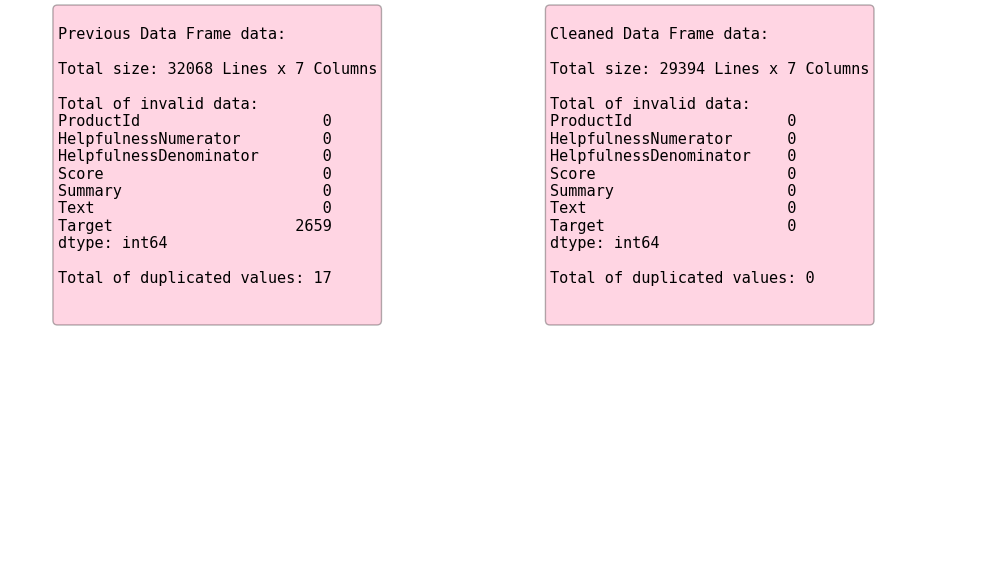

In [124]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.axis('off')

previous_data_text = f"""
Previous Data Frame data:

Total size: {df.shape[0]} Lines x {df.shape[1]} Columns

Total of invalid data:
{df.isna().sum()}

Total of duplicated values: {df.duplicated().sum()}

"""

plt.text(
    0.1, 0.5,
    previous_data_text,
    fontsize=11,
    family='monospace',
    bbox=dict(boxstyle='round', facecolor='#ff75a5', alpha=0.3)
  )


plt.subplot(1, 2, 2)
plt.axis('off')

cleaned_data_text = f"""
Cleaned Data Frame data:

Total size: {df_clean.shape[0]} Lines x {df_clean.shape[1]} Columns

Total of invalid data:
{df_clean.isna().sum()}

Total of duplicated values: {df_clean.duplicated().sum()}

"""

plt.text(
    0.1, 0.5,
    cleaned_data_text,
    fontsize=11,
    family='monospace',
    bbox=dict(boxstyle='round', facecolor='#ff75a5', alpha=0.3)
  )

plt.tight_layout()
plt.show()